In [9]:
import kagglehub
import pandas as pd
import numpy as np

In [10]:
# Download dataset from Kaggle Hub
path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python"
)

print("Dataset downloaded at:", path)

Dataset downloaded at: /Users/kimliya/.cache/kagglehub/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/versions/1


In [11]:
# Load training data
path = f"{path}/Mall_Customers.csv"
df = pd.read_csv(path)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [12]:
# Drop CustomerID as it is not relevant for clustering
df_cluster = df.drop("CustomerID", axis=1)

# Encode Gender (optional)
df_cluster['Gender'] = df_cluster['Gender'].map({'Male':0, 'Female':1})

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cluster)

## Determine the Elbow

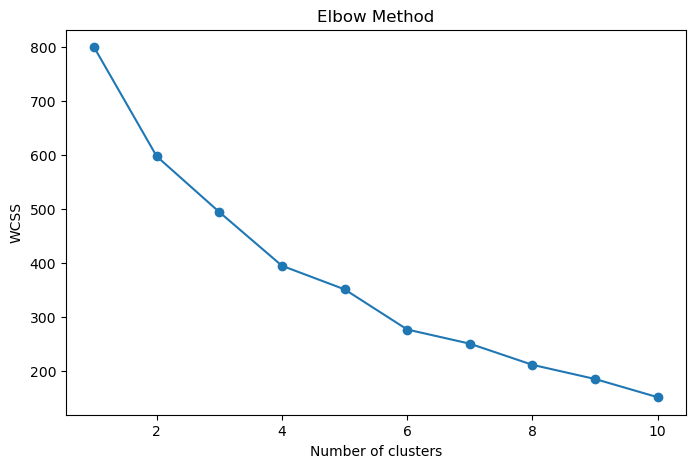

In [17]:
from sklearn.cluster import KMeans
wcss = []  # Within-cluster sum of squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot elbow
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [26]:
# Let's choose 5 clusters based on elbow
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(scaled_features)

In [27]:
# View cluster distribution
df_cluster['Cluster'].value_counts()

Cluster
0    51
3    49
2    42
4    38
1    20
Name: count, dtype: int64

In [28]:
# Cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=df_cluster.columns[:-1])
print(centers_df)

     Gender        Age  Annual Income (k$)  Spending Score (1-100)
0  0.490196  56.470588           46.098039               39.313725
1  0.000000  39.500000           85.150000               14.050000
2  0.000000  28.690476           60.904762               70.238095
3  1.000000  37.897959           82.122449               54.448980
4  1.000000  27.315789           38.842105               56.210526


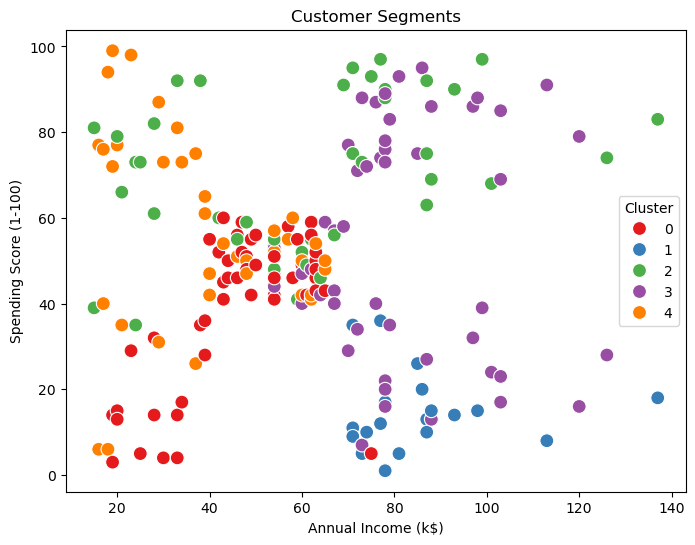

In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    palette='Set1', 
    data=df_cluster, 
    s=100
)
plt.title("Customer Segments")
plt.show()